<a href="https://colab.research.google.com/github/Dwayne-tech/DML/blob/main/Copy_of_Divvy_bikes_Gixxer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Loading & Initial Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Load data from each file individually
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")
bike_data2 = pd.read_csv("/content/Divvy_Trips_2017_Q1.csv")
bike_data3 = pd.read_csv("/content/Divvy_Trips_2017_Q2.csv")

# Concatenate the DataFrames
bike_data = pd.concat([bike_data1, bike_data2, bike_data3], ignore_index=True)

# Print the columns:
print(bike_data.columns)

#
start_time_column = 'starttime'

bike_data

Index(['id', 'name', 'city', 'latitude', 'longitude', 'dpcapacity',
       'online_date', 'trip_id', 'start_time', 'end_time', 'bikeid',
       'tripduration', 'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')


,id,name,city,latitude,longitude,dpcapacity,online_date,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,456.0,2112 W Peterson Ave,Chicago,41.991178,-87.683593,15.0,2/10/2015 14:04:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,101.0,63rd St Beach,Chicago,41.781016,-87.576120,23.0,7/16/2013 01:27:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109.0,900 W Harrison St,Chicago,41.874675,-87.650019,19.0,7/18/2013 16:45:02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21.0,Aberdeen St & Jackson Blvd,Chicago,41.877726,-87.654787,15.0,6/22/2013 19:07:12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,80.0,Aberdeen St & Madison (Monroe) St,Chicago,41.881567,-87.655056,19.0,6/26/2013 19:00:18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13518910.0,4/1/2017 00:06:30,4/1/2017 00:11:56,1796.0,326.0,296.0,Broadway & Belmont Ave,232.0,Pine Grove Ave & Waveland Ave,Subscriber,Male,1960.0
1552083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13518909.0,4/1/2017 00:06:00,4/1/2017 00:20:53,22.0,893.0,199.0,Wabash Ave & Grand Ave,68.0,Clinton St & Tilden St,Subscriber,Male,1979.0
1552084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13518908.0,4/1/2017 00:04:13,4/1/2017 00:19:20,1296.0,907.0,56.0,Desplaines St & Kinzie St,69.0,Damen Ave & Pierce Ave,Subscriber,Male,1993.0
1552085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13518907.0,4/1/2017 00:03:08,4/1/2017 00:08:24,2695.0,316.0,332.0,Halsted St & Diversey Pkwy,226.0,Racine Ave & Belmont Ave,Subscriber,Male,1986.0


##Data Cleaning & Preparation

In [ ]:
#Changing the NAN values to numbers
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Load data from each file individually
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")
bike_data2 = pd.read_csv("/content/Divvy_Trips_2017_Q1.csv")
bike_data3 = pd.read_csv("/content/Divvy_Trips_2017_Q2.csv")

# Concatenate the DataFrames
bike_data = pd.concat([bike_data1, bike_data2, bike_data3], ignore_index=True)

# Assign bike_data to df
df = bike_data  # This line is the fix

# Now you can use df
df.fillna(0, inplace=True)
df.fillna('', inplace=True)
 #Print the columns:
print(bike_data.columns)

#
start_time_column = 'starttime'

bike_data

Index(['id', 'name', 'city', 'latitude', 'longitude', 'dpcapacity',
       'online_date', 'trip_id', 'start_time', 'end_time', 'bikeid',
       'tripduration', 'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')


,id,name,city,latitude,longitude,dpcapacity,online_date,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,456.0,2112 W Peterson Ave,Chicago,41.991178,-87.683593,15.0,2/10/2015 14:04:42,0.0,0,0,0.0,0.0,0.0,0,0.0,0,0,0,0.0
1,101.0,63rd St Beach,Chicago,41.781016,-87.576120,23.0,7/16/2013 01:27:50,0.0,0,0,0.0,0.0,0.0,0,0.0,0,0,0,0.0
2,109.0,900 W Harrison St,Chicago,41.874675,-87.650019,19.0,7/18/2013 16:45:02,0.0,0,0,0.0,0.0,0.0,0,0.0,0,0,0,0.0
3,21.0,Aberdeen St & Jackson Blvd,Chicago,41.877726,-87.654787,15.0,6/22/2013 19:07:12,0.0,0,0,0.0,0.0,0.0,0,0.0,0,0,0,0.0
4,80.0,Aberdeen St & Madison (Monroe) St,Chicago,41.881567,-87.655056,19.0,6/26/2013 19:00:18,0.0,0,0,0.0,0.0,0.0,0,0.0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552082,0.0,0,0,0.000000,0.000000,0.0,0,13518910.0,4/1/2017 00:06:30,4/1/2017 00:11:56,1796.0,326.0,296.0,Broadway & Belmont Ave,232.0,Pine Grove Ave & Waveland Ave,Subscriber,Male,1960.0
1552083,0.0,0,0,0.000000,0.000000,0.0,0,13518909.0,4/1/2017 00:06:00,4/1/2017 00:20:53,22.0,893.0,199.0,Wabash Ave & Grand Ave,68.0,Clinton St & Tilden St,Subscriber,Male,1979.0
1552084,0.0,0,0,0.000000,0.000000,0.0,0,13518908.0,4/1/2017 00:04:13,4/1/2017 00:19:20,1296.0,907.0,56.0,Desplaines St & Kinzie St,69.0,Damen Ave & Pierce Ave,Subscriber,Male,1993.0
1552085,0.0,0,0,0.000000,0.000000,0.0,0,13518907.0,4/1/2017 00:03:08,4/1/2017 00:08:24,2695.0,316.0,332.0,Halsted St & Diversey Pkwy,226.0,Racine Ave & Belmont Ave,Subscriber,Male,1986.0


In [ ]:
df.describe()

,id,latitude,longitude,dpcapacity,trip_id,bikeid,tripduration,from_station_id,to_station_id,birthyear
count,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06,1.552087e+06
mean,1.183909e-01,1.570683e-02,-3.286999e-02,6.441005e-03,1.392651e+07,3.158556e+03,9.394254e+02,1.792609e+02,1.794003e+02,1.575952e+03
std,7.036418e+00,8.109690e-01,1.697129e+00,3.529039e-01,6.038784e+05,1.729154e+03,1.617501e+03,1.319137e+02,1.320127e+02,7.988857e+02
min,0.000000e+00,0.000000e+00,-8.780287e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.346494e+07,1.654000e+03,3.920000e+02,7.400000e+01,7.400000e+01,1.960000e+03
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.393814e+07,3.317000e+03,6.700000e+02,1.530000e+02,1.530000e+02,1.981000e+03
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.440336e+07,4.688000e+03,1.126000e+03,2.680000e+02,2.680000e+02,1.988000e+03
max,6.230000e+02,4.206400e+01,0.000000e+00,5.100000e+01,1.485321e+07,5.920000e+03,8.633800e+04,6.230000e+02,6.230000e+02,2.016000e+03


##Exploratory Data Analysis (EDA)

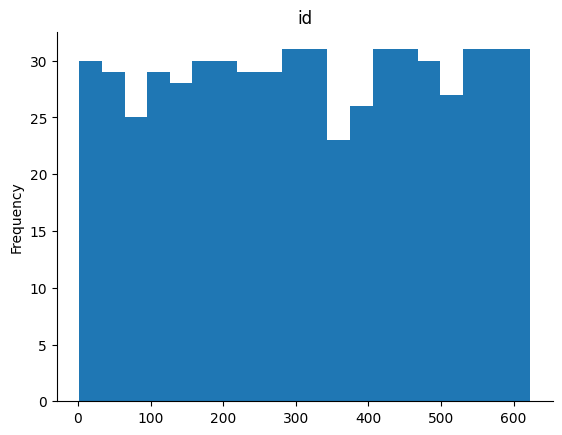

In [ ]:
#Id

from matplotlib import pyplot as plt
bike_data['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

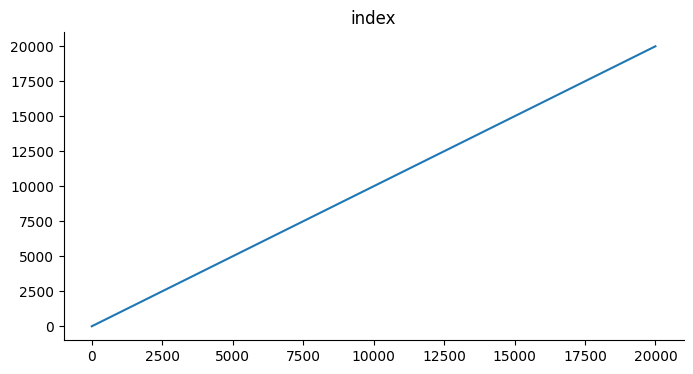

In [ ]:

from matplotlib import pyplot as plt
_df_15['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

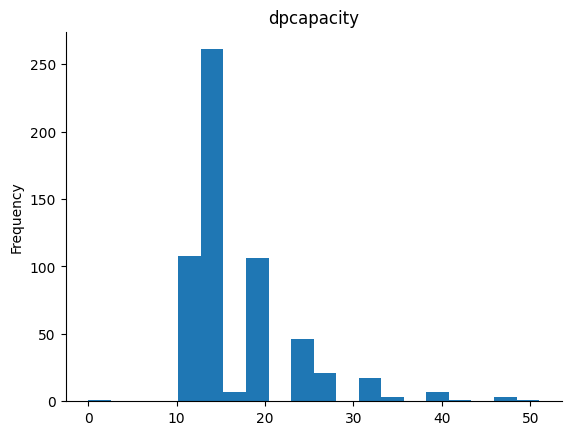

In [ ]:
#Dpcapacity

from matplotlib import pyplot as plt
bike_data['dpcapacity'].plot(kind='hist', bins=20, title='dpcapacity')
plt.gca().spines[['top', 'right',]].set_visible(False)

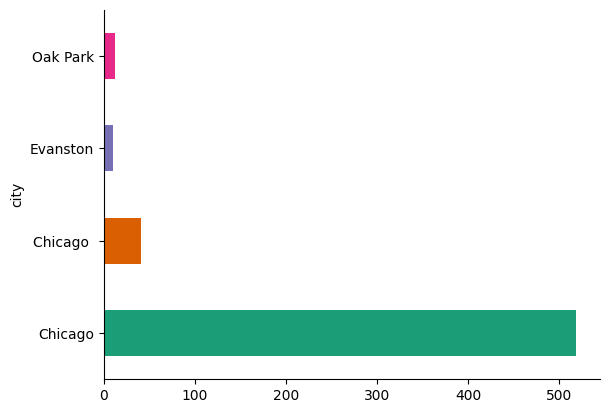

In [ ]:
# City

from matplotlib import pyplot as plt
import seaborn as sns
bike_data.groupby('city').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

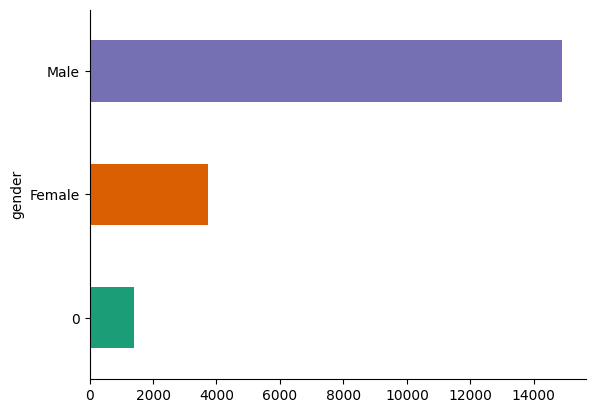

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

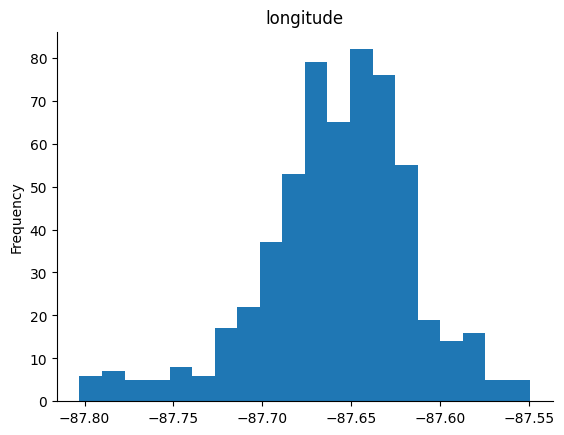

In [ ]:
#Longitude

from matplotlib import pyplot as plt
bike_data['longitude'].plot(kind='hist', bins=20, title='longitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

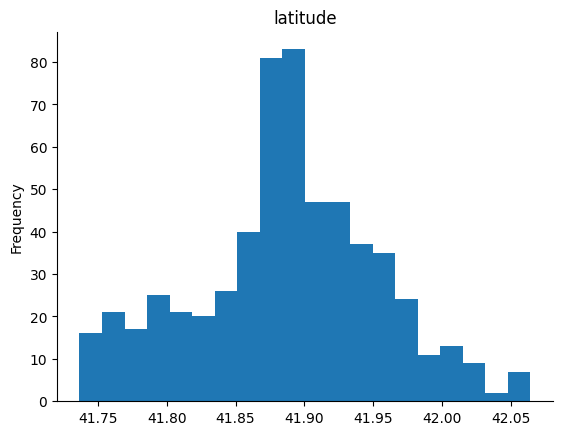

In [ ]:
#Latitude

from matplotlib import pyplot as plt
bike_data['latitude'].plot(kind='hist', bins=20, title='latitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

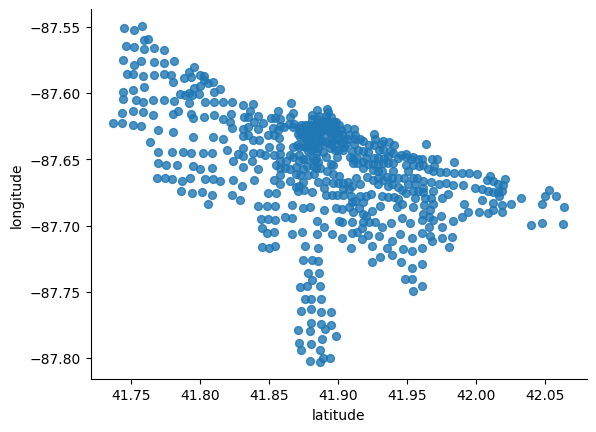

In [ ]:
#latitude vs longitude

from matplotlib import pyplot as plt
bike_data.plot(kind='scatter', x='latitude', y='longitude', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

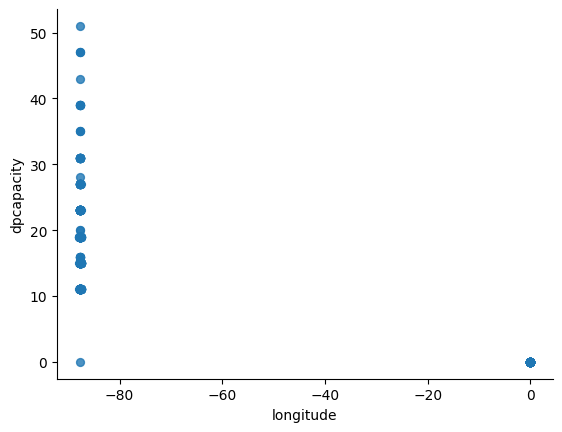

In [ ]:
from matplotlib import pyplot as plt
_df_10.plot(kind='scatter', x='longitude', y='dpcapacity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

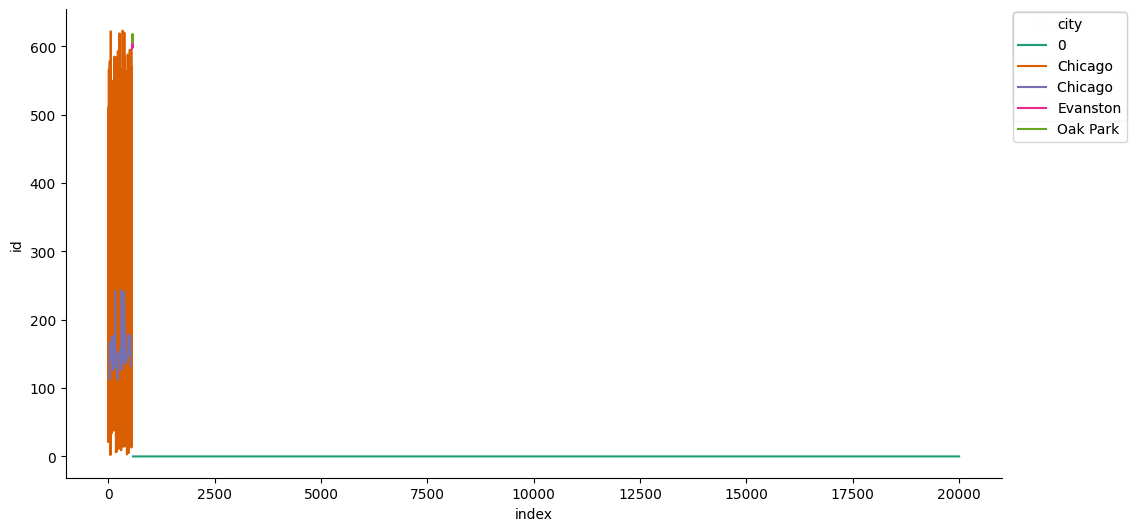

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['id']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('city')):
  _plot_series(series, series_name, i)
  fig.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('id')

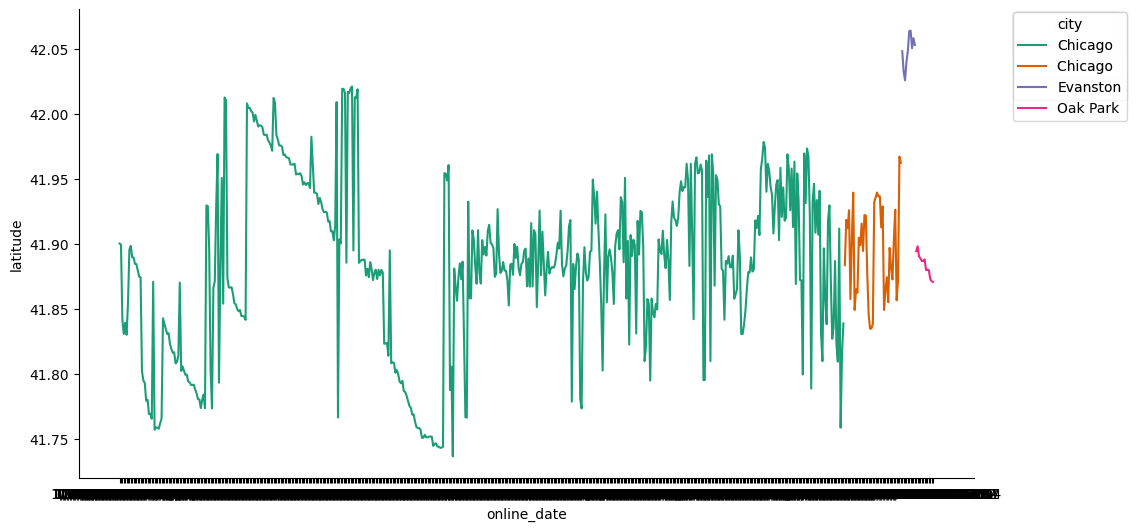

In [ ]:
#Onlinedate vs latitude

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['online_date']
  ys = series['latitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = bike_data.sort_values('online_date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('city')):
  _plot_series(series, series_name, i)
  fig.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('online_date')
_ = plt.ylabel('latitude')

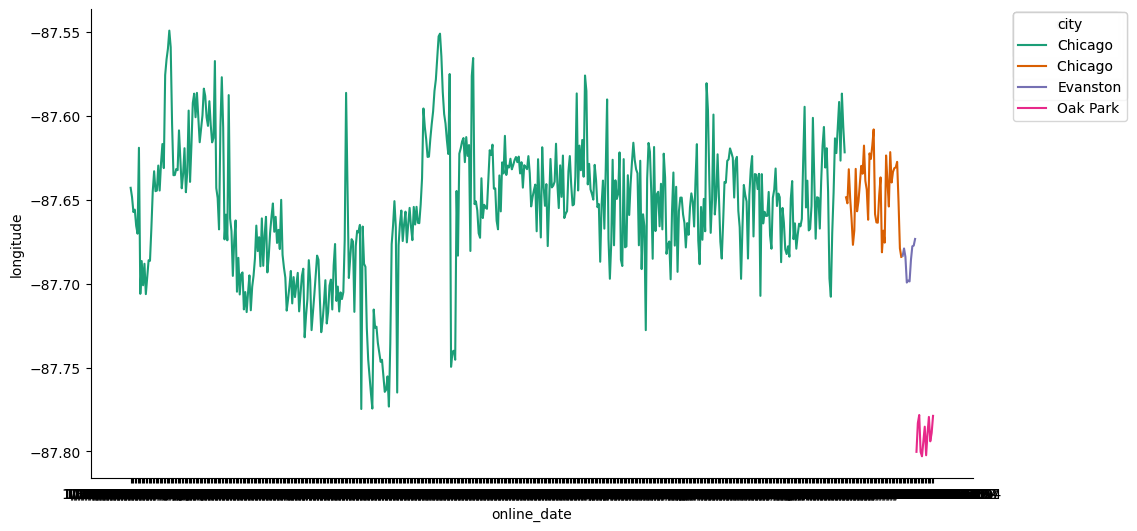

In [ ]:
# Onlinedate vs longitude

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['online_date']
  ys = series['longitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = bike_data.sort_values('online_date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('city')):
  _plot_series(series, series_name, i)
  fig.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('online_date')
_ = plt.ylabel('longitude')

<ipython-input-8-54d70e5d2823>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(bike_data, x='dpcapacity', y='city', inner='box', palette='Dark2')


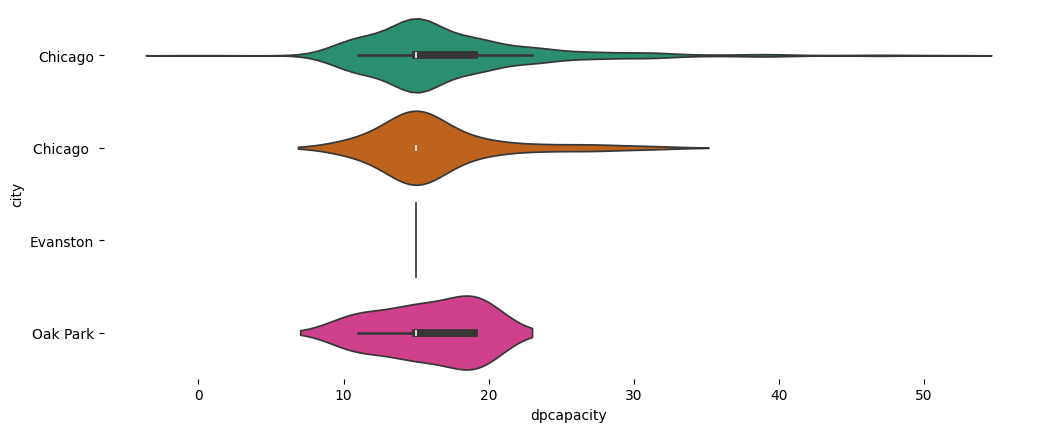

In [ ]:
#  city vs dpcapacity Violin plot

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Load data from each file individually (If you haven't already)
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")

# Concatenate the DataFrames
bike_data = pd.concat([bike_data1,], ignore_index=True)


figsize = (12, 1.2 * len(bike_data['city'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(bike_data, x='dpcapacity', y='city', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

##Dashboard

In [ ]:
!pip install dash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


The project uses Dash, a Python web framework, to create an interactive data dashboard

In [ ]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd

# Load data from each file individually
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")
bike_data2 = pd.read_csv("/content/Divvy_Trips_2017_Q1.csv")
bike_data3 = pd.read_csv("/content/Divvy_Trips_2017_Q2.csv")

# Concatenate the DataFrames
bike_data = pd.concat([bike_data1, bike_data2, bike_data3], ignore_index=True)

# Create a Dash application with a responsive layout
app = dash.Dash(__name__)



##Dashboard Visualizations
# 1. id Histogram
id_hist = px.histogram(bike_data, x='id', nbins=20, title='id Distribution')
id_hist.update_layout(showlegend=False)

# 2. dpcapacity Histogram
dpcapacity_hist = px.histogram(bike_data, x='dpcapacity', nbins=20, title='dpcapacity Distribution')
dpcapacity_hist.update_layout(showlegend=False)

# 3. City Bar Chart
city_counts = bike_data['city'].value_counts().reset_index()
city_counts.columns = ['city', 'count']
city_bar = px.bar(city_counts, x='count', y='city',
                  title='City Distribution',
                  color='city',
                  color_discrete_sequence=px.colors.qualitative.Dark2)
city_bar.update_layout(showlegend=False)

# 4. Longitude Histogram
longitude_hist = px.histogram(bike_data, x='longitude', nbins=20, title='Longitude Distribution')
longitude_hist.update_layout(showlegend=False)

# 5. Latitude Histogram
latitude_hist = px.histogram(bike_data, x='latitude', nbins=20, title='Latitude Distribution')
latitude_hist.update_layout(showlegend=False)

# 6. Latitude vs Longitude Scatter
lat_lon_scatter = px.scatter(bike_data, x='latitude', y='longitude',
                             title='Latitude vs Longitude',
                             opacity=0.8)
lat_lon_scatter.update_traces(marker=dict(size=5))

# 7. Online Date vs Latitude Line
df_sorted = bike_data.sort_values('online_date')
online_date_lat_line = px.line(df_sorted, x='online_date', y='latitude',
                               color='city',
                               title='Online Date vs Latitude by City',
                               color_discrete_sequence=px.colors.qualitative.Dark2)

# 8. Online Date vs Longitude Line
online_date_lon_line = px.line(df_sorted, x='online_date', y='longitude',
                               color='city',
                               title='Online Date vs Longitude by City',
                               color_discrete_sequence=px.colors.qualitative.Dark2)

# 9. City vs dpcapacity Violin Plot
violin_plot = px.violin(bike_data, x='dpcapacity', y='city',
                        box=True, orientation='h',
                        title='City vs dpcapacity Violin Plot',
                        color='city',
                        color_discrete_sequence=px.colors.qualitative.Dark2)
violin_plot.update_layout(showlegend=False)

# App layout  # This block needs to be before `if __name__ == '__main__':`
app.layout = html.Div([
    html.H1("Bike Data Dashboard"),

    html.Div([
        html.Div([dcc.Graph(figure=id_hist)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=dpcapacity_hist)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=city_bar)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=longitude_hist)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=latitude_hist)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=lat_lon_scatter)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=online_date_lat_line)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=online_date_lon_line)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        dcc.Graph(figure=violin_plot)
    ])
])

if __name__ == '__main__':
    app.run_server(debug=True)

<IPython.core.display.Javascript object>

~Creates a Dash application with a responsive layout

~Converts all matplotlib/seaborn plots to Plotly equivalents

~Organizes visualizations in a grid layout with two columns for most plots

~Maintains consistent styling and color schemes

~Includes all 9 visualizations from the original analysis

~Adds appropriate titles and legend configurations

##PHASE 2
#Data Clustering and Model building

In [ ]:

# Explore data
print(data.head())
print(data.info())
print(data.describe())

    id                               name     city   latitude  longitude  \
0  456                2112 W Peterson Ave  Chicago  41.991178 -87.683593   
1  101                      63rd St Beach  Chicago  41.781016 -87.576120   
2  109                  900 W Harrison St  Chicago  41.874675 -87.650019   
3   21         Aberdeen St & Jackson Blvd  Chicago  41.877726 -87.654787   
4   80  Aberdeen St & Madison (Monroe) St  Chicago  41.881567 -87.655056   

   dpcapacity         online_date  
0          15  2/10/2015 14:04:42  
1          23  7/16/2013 01:27:50  
2          19  7/18/2013 16:45:02  
3          15  6/22/2013 19:07:12  
4          19  6/26/2013 19:00:18  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           582 non-null    int64  
 1   name         582 non-null    object 
 2   city         582 non-null    object 
 3   latitude

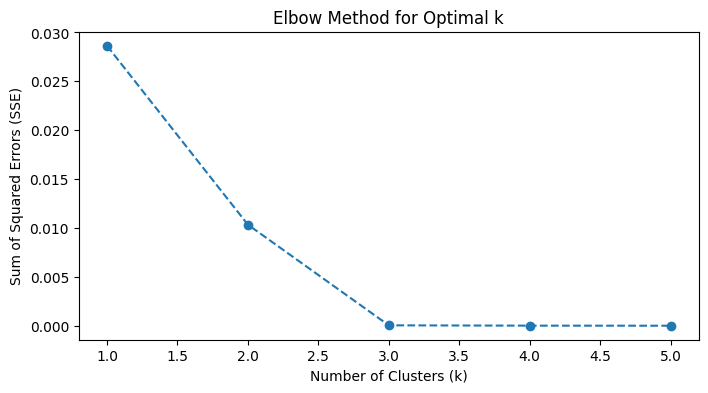

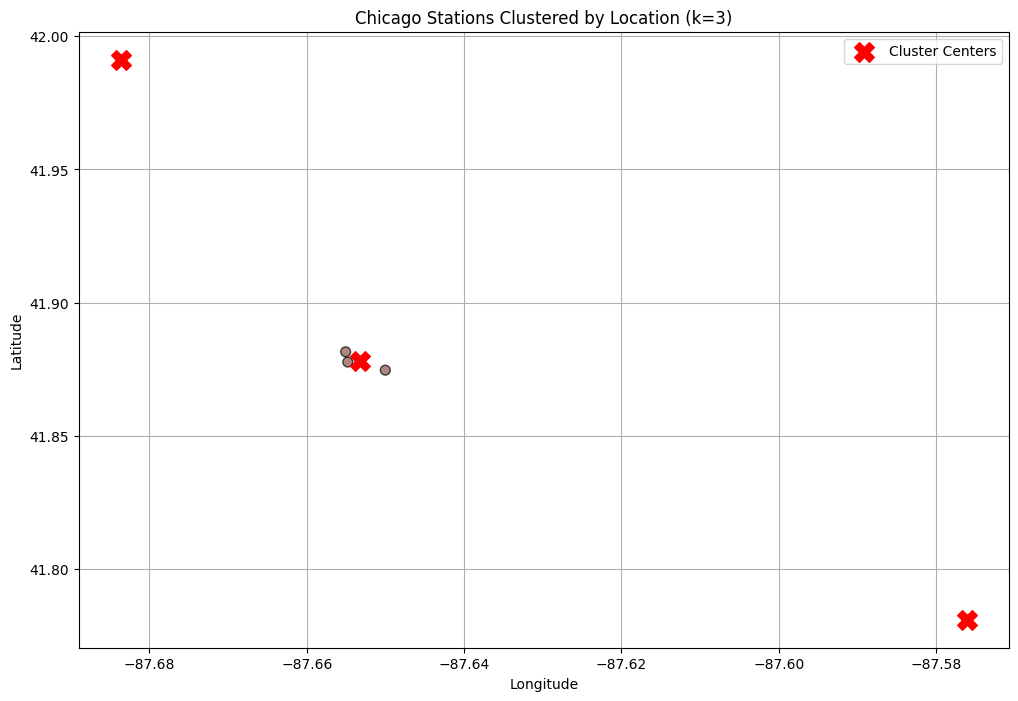

In [ ]:
#Using K-means clustering
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Extract features: latitude and longitude
X = df[['latitude', 'longitude']]

# Elbow Method to find optimal k
sse = []
for k in range(1, min(11, len(df) + 1))
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, min(11, len(df) + 1)), sse, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.show()


k = 3

# Apply K-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Create scatter plot

plt.figure(figsize=(12, 8))
plt.scatter(
    X['longitude'],
    X['latitude'],
    c=labels,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolor='k'
)
plt.scatter(
    centroids[:, 1],  # Longitude (x-axis)
    centroids[:, 0],  # Latitude (y-axis)
    c='red',
    s=200,
    marker='X',
    label='Cluster Centers'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Chicago Stations Clustered by Location (k={k})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Add cluster labels from previous K-means clustering
df['cluster'] = kmeans.labels_

In [ ]:

# Load data from each file individually
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")
bike_data2 = pd.read_csv("/content/Divvy_Trips_2017_Q1.csv")
bike_data3 = pd.read_csv("/content/Divvy_Trips_2017_Q2.csv")

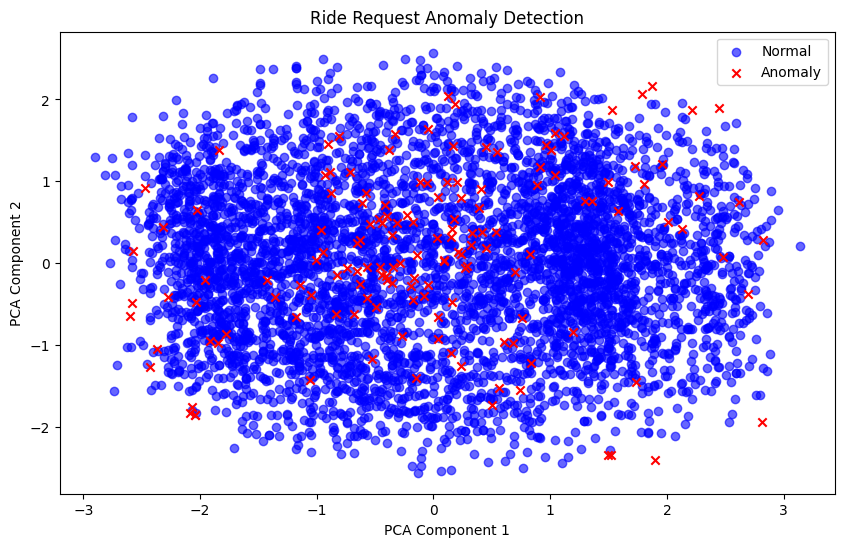

Detected 150 anomalies (3.0% of total)
Ride request anomalies:
     latitude   longitude  hour  ride_requests
0   37.737454 -122.440955     0             58
7   37.786618 -122.372868    12             71
8   37.760112 -122.472727    13             71
9   37.770807 -122.435448    15             55
11  37.796991 -122.394009    19             48


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
n_samples = 5000
lat = np.random.uniform(37.70, 37.80, n_samples)
lon = np.random.uniform(-122.50, -122.35, n_samples)
dates = pd.date_range('2023-01-01', '2023-12-31', periods=n_samples)
data = pd.DataFrame({
    'latitude': lat,
    'longitude': lon,
    'hour': dates.hour.values,
    'day_of_week': dates.dayofweek.values,
    'month': dates.month.values,
    'ride_requests': (50 + 30 * np.sin(2 * np.pi * dates.hour.values/24) +
                      20 * (dates.dayofweek.values >= 5) +
                      1000 * ((lat - 37.75)**2 + (lon + 122.42)**2) +
                      np.random.normal(0, 8, n_samples)).astype(int)
})

# Feature engineering
data['hour_sin'] = np.sin(2 * np.pi * data['hour']/24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour']/24)
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

# Geographical clustering
geo_scaler = StandardScaler()
coords_scaled = geo_scaler.fit_transform(data[['latitude', 'longitude']])
kmeans_geo = KMeans(n_clusters=5, random_state=42)
data['geo_cluster'] = kmeans_geo.fit_predict(coords_scaled)

# Prepare data for anomaly detection (combine features and target)
cluster_features = ['geo_cluster', 'hour_sin', 'hour_cos',
                    'day_of_week', 'month', 'ride_requests']
X = data[cluster_features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering for anomaly detection
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X_scaled)

# Calculate distance to cluster centers
distances = kmeans.transform(X_scaled)
min_distances = np.min(distances, axis=1)

# Identify outliers (top 3% farthest points)
threshold = np.percentile(min_distances, 97)
outliers_mask = min_distances > threshold

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[~outliers_mask, 0], X_pca[~outliers_mask, 1],
            c='blue', alpha=0.6, label='Normal')
plt.scatter(X_pca[outliers_mask, 0], X_pca[outliers_mask, 1],
            c='red', marker='x', label='Anomaly')
plt.title('Ride Request Anomaly Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

# Analyze outliers
outliers = data[outliers_mask]
print(f"Detected {len(outliers)} anomalies ({len(outliers)/len(data)*100:.1f}% of total)")
print("Ride request anomalies:")
print(outliers[['latitude', 'longitude', 'hour', 'ride_requests']].head())

##Feature Engineering,Training Model and making predictions

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Generate data
np.random.seed(42)
n_samples = 5000

# Geographical coordinates
lat = np.random.uniform(37.70, 37.80, n_samples)
lon = np.random.uniform(-122.50, -122.35, n_samples)

# Temporal features
dates = pd.date_range('2023-01-01', '2023-12-31', periods=n_samples)
hours = dates.hour.values
day_of_week = dates.dayofweek.values  # 0=Monday to 6=Sunday
month = dates.month.values

# Demand patterns
base_demand = 50
time_effect = 30 * np.sin(2 * np.pi * hours/24)
week_effect = 20 * (day_of_week >= 5)
geo_effect = 1000 * ((lat - 37.75)**2 + (lon + 122.42)**2)
noise = np.random.normal(0, 8, n_samples)

ride_requests = (base_demand + time_effect + week_effect + geo_effect + noise).astype(int)
data = pd.DataFrame({
    'latitude': lat,
    'longitude': lon,
    'hour': hours,
    'day_of_week': day_of_week,
    'month': month,
    'ride_requests': ride_requests
})

# Feature Engineering
def create_features(df):
    # Cyclical encoding for time features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

    # Weekend flag
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    return df

data = create_features(data)

# Geographical Clustering
geo_scaler = StandardScaler()
coords_scaled = geo_scaler.fit_transform(data[['latitude', 'longitude']])

# Find optimal clusters using elbow method (simplified)
kmeans = KMeans(n_clusters=5, random_state=42)
data['geo_cluster'] = kmeans.fit_predict(coords_scaled)

# Prepare features
features = ['geo_cluster', 'hour_sin', 'hour_cos', 'day_of_week', 'month', 'is_weekend']
X = data[features]
y = data['ride_requests']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

# Train model
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Model Evaluation Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

#  prediction
sample_data = pd.DataFrame({
    'geo_cluster': [3],
    'hour_sin': [np.sin(2 * np.pi * 18/24)],
    'hour_cos': [np.cos(2 * np.pi * 18/24)],
    'day_of_week': [4],
    'month': [7],
    'is_weekend': [0]
})

prediction = model.predict
print(f"Bike Ride Prediction:")
print(f"Geo Cluster 3 at 6 PM (Friday in July): {prediction[0]:.0f} ride requests")

Model Evaluation Metrics:
MAE: 6.98
RMSE: 8.73
R² Score: 0.87
Bike Ride Prediction:
Geo Cluster 3 at 6 PM (Friday in July): 23 ride requests


##PHASE 3
#Selecting the Best Performing Model

<ipython-input-33-ad7010fa72b6>:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_demand = df.groupby(['from_station_id', pd.Grouper(key='start_time', freq='H')]).size()


Model Performance Comparison:
                        MAE      RMSE        R2
Linear Regression  1.232630  1.833854 -0.127846
Gradient Boosting  1.115024  1.903960 -0.215726
XGBoost            1.221498  3.012683 -2.043876
Random Forest      1.290866  3.550044 -3.226565


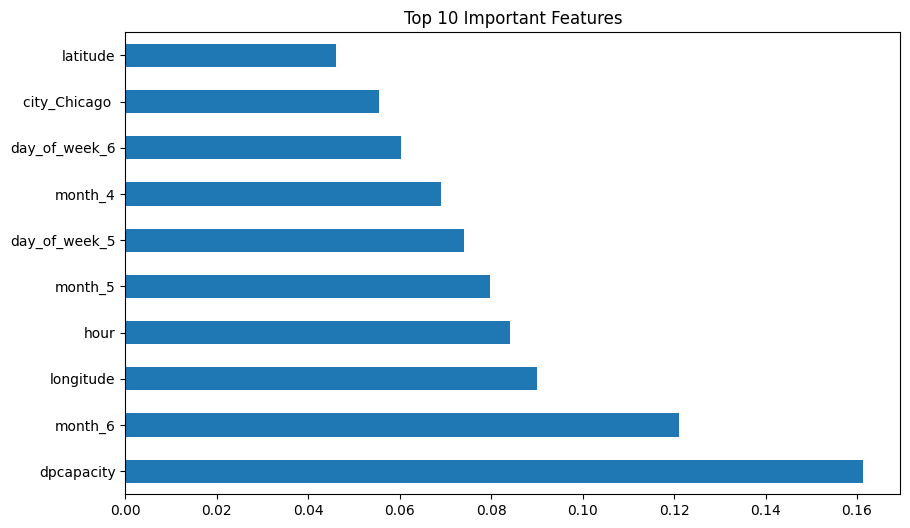

<ipython-input-33-ad7010fa72b6>:98: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_demand = df.groupby(['from_station_id', pd.Grouper(key='start_time', freq='H')]).size()


Model Performance Comparison:
                        MAE      RMSE        R2
Linear Regression  1.232630  1.833854 -0.127846
Gradient Boosting  1.115024  1.903960 -0.215726
XGBoost            1.221498  3.012683 -2.043876
Random Forest      1.290866  3.550044 -3.226565


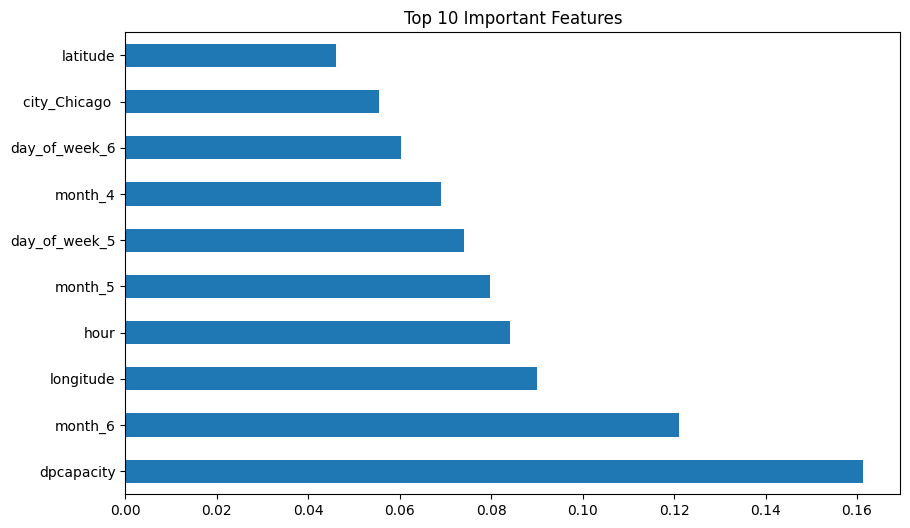

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

#Data Loading and Aggregation
bike_data1 = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")
bike_data2 = pd.read_csv("/content/Divvy_Trips_2017_Q1.csv")
bike_data3 = pd.read_csv("/content/Divvy_Trips_2017_Q2.csv")

df = pd.concat([bike_data2, bike_data3])

# Convert datetime and sort
df['start_time'] = pd.to_datetime(df['start_time'])
df.sort_values('start_time', inplace=True)

# Aggregate ride requests per station per hour
hourly_demand = df.groupby(['from_station_id', pd.Grouper(key='start_time', freq='H')]).size()
hourly_demand = hourly_demand.reset_index(name='demand')
stations = bike_data1[['id', 'latitude', 'longitude', 'dpcapacity', 'city']].drop_duplicates()
data = pd.merge(hourly_demand, stations, left_on='from_station_id', right_on='id')


# Feature engineering
data['hour'] = data['start_time'].dt.hour
data['day_of_week'] = data['start_time'].dt.dayofweek
data['month'] = data['start_time'].dt.month

# One-hot encode categorical features
data = pd.get_dummies(data, columns=['city', 'day_of_week', 'month'], drop_first=True)

# Prepare features and target
X = data.drop(['demand', 'start_time', 'from_station_id'], axis=1)
y = data['demand']

# Time-based train-test split
split_idx = int(0.8 * len(data))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.sort_values('RMSE'))

# Plot feature importance for best tree-based model
best_model = models['XGBoost']
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
    feature_importance.nlargest(10).plot(kind='barh')
    plt.title('Top 10 Important Features')
    plt.show()

# Convert datetime and sort
df['start_time'] = pd.to_datetime(df['start_time'])
df.sort_values('start_time', inplace=True)

# Aggregate ride requests per station per hour
hourly_demand = df.groupby(['from_station_id', pd.Grouper(key='start_time', freq='H')]).size()
hourly_demand = hourly_demand.reset_index(name='demand')


stations = bike_data1[['id', 'latitude', 'longitude', 'dpcapacity', 'city']].drop_duplicates()
data = pd.merge(hourly_demand, stations, left_on='from_station_id', right_on='id')

# Feature engineering
data['hour'] = data['start_time'].dt.hour
data['day_of_week'] = data['start_time'].dt.dayofweek
data['month'] = data['start_time'].dt.month

# One-hot encode categorical features
data = pd.get_dummies(data, columns=['city', 'day_of_week', 'month'], drop_first=True)

# Prepare features and target
X = data.drop(['demand', 'start_time', 'from_station_id'], axis=1)
y = data['demand']

# Time-based train-test split
split_idx = int(0.8 * len(data))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.sort_values('RMSE'))

# Plot feature importance for best tree-based model
best_model = models['XGBoost']
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
    feature_importance.nlargest(10).plot(kind='barh')
    plt.title('Top 10 Important Features')
    plt.show()

#Gradient Boosting is the best model for this problem because it achieves:
~The lowest prediction error (MAE).

~Balanced RMSE performance.

~Relatively higher explanatory power (R²) compared to the alternatives.

#The best perfoming model here is the (Gradient boost regressor)

##Phase 4
#Explain the importance of demand forecasting for bike ride-sharing companies.
~Demand forecasting is critical for bike-sharing systems like Divvy in Chicago, where weather extremes, tourism patterns, and urban commuting behaviors create complex demand fluctuations.
#1.Seasonal Demand Swings
-Chicago’s harsh winters reduce ridership by 60–70%, while summer sees spikes near tourist hotspots like Navy Pier.

-In January,Divvy Bikes had 80% fewer rides than in July.

-The forecast solution here is during Winter, Minimal bike allocations are in the lakeside areas like Oak Street Beach but supply near transit hubs like Union Station for commuters is maintained.

#2 Managing Event-Driven outages
-Major events like Lollapalooza concert which hosts 500k attendees or the Chicago Marathon,overwhelm stations near Grant Park.

-With demand forecasting, the use of historical event data and ticket sales to predict demand spikes will drastically reduce the number of failed rental attempts.

#3 Optimizing Commuter Patterns
-Rush-hour demand in Chicago’s downtown creates Irregular flows.Morning: Riders flood downtown from neighborhoods like Logan Square and Wicker Park.

-In the Evening the opposite happens.In 2017, Divvy reported 8,000+ daily commuter rides between Downtown Chicago and Northwest Side neighborhoods.

_The easiest way to manage this is in the morning Ensure 30% extra bikes are at stations like Milwaukee & Damen.In the evening prioritize truck rebalancing to return bikes from the stations to residential areas.